<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/HES17Sim002.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import matplotlib.pyplot as plt

alpha = 0.2
beta = 0.001
steps = 50
N = 20


In [3]:
def initialize_with_seeds(D, N, seed=0):
    rng = np.random.default_rng(seed)
    s = np.zeros([N]*D)
    center = tuple([N//2]*D)
    s[center] = 1.0
    s += 0.01 * rng.standard_normal([N]*D)
    return s

def evolve_field(s, alpha=0.2, beta=0.001, steps=50, clip=10.0):
    for _ in range(steps):
        lap = np.zeros_like(s)
        for a in range(s.ndim):
            lap += np.roll(s, 1, axis=a) + np.roll(s, -1, axis=a) - 2*s
        s = s + alpha*lap - beta*(s**3)
        s = np.clip(s, -clip, clip)
        s -= s.mean()
    return s

def plot_power_spectrum(s, dx=1.0, title=""):
    F = np.fft.fftn(s)
    P = np.abs(F)**2
    P = np.fft.fftshift(P)
    k_axes = [np.fft.fftshift(2*np.pi*np.fft.fftfreq(n, d=dx)) for n in s.shape]
    K = np.meshgrid(*k_axes, indexing='ij')
    k_mag = np.sqrt(sum(Ki**2 for Ki in K))
    k_bins = np.linspace(0, k_mag.max(), 50)
    P_radial = []
    for i in range(len(k_bins)-1):
        mask = (k_mag >= k_bins[i]) & (k_mag < k_bins[i+1])
        P_radial.append(P[mask].mean() if np.any(mask) else 0.0)
    plt.figure(figsize=(6,4))
    plt.loglog(k_bins[:-1], P_radial, 'o-', label=title)
    plt.xlabel('k'); plt.ylabel('P(k)')
    plt.title(f"Power Spectrum: {title}")
    plt.grid(True, alpha=0.3)
    plt.legend(); plt.show()


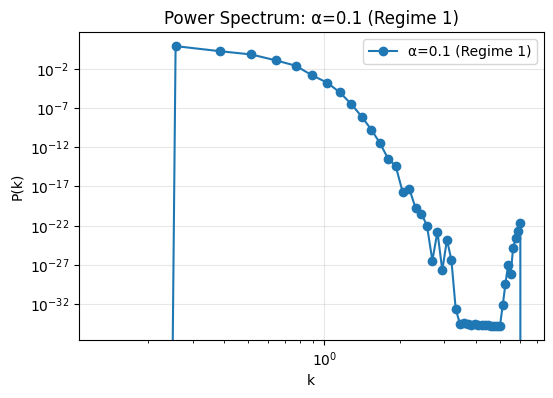

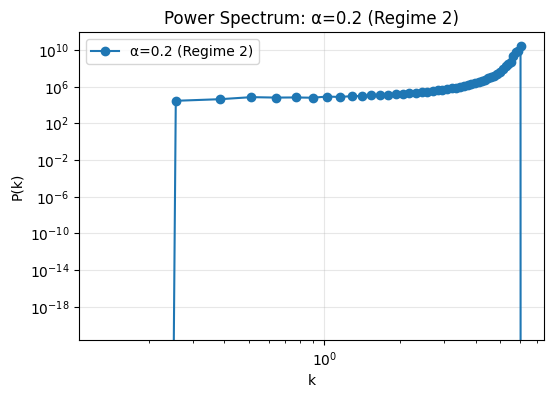

In [4]:
# Regime 1: α = 0.1 (diffusion-limited)
s1 = evolve_field(initialize_with_seeds(4, N, seed=0), alpha=0.1, beta=beta, steps=steps)
plot_power_spectrum(s1, title="α=0.1 (Regime 1)")

# Regime 2: α = 0.2 (nonlinearity-arrested)
s2 = evolve_field(initialize_with_seeds(4, N, seed=0), alpha=0.2, beta=beta, steps=steps)
plot_power_spectrum(s2, title="α=0.2 (Regime 2)")


In [2]:
import numpy as np
import matplotlib.pyplot as plt

def initialize_with_seeds(D, N, seed=0):
    rng = np.random.default_rng(seed)
    s = np.zeros([N]*D)
    center = tuple([N//2]*D)
    s[center] = 1.0
    s += 0.01 * rng.standard_normal([N]*D)
    return s

def evolve_field(s, alpha=0.2, beta=0.001, steps=50, clip=10.0):
    for _ in range(steps):
        lap = np.zeros_like(s)
        for a in range(s.ndim):
            lap += np.roll(s, 1, axis=a) + np.roll(s, -1, axis=a) - 2*s
        s = s + alpha*lap - beta*(s**3)
        s = np.clip(s, -clip, clip)
        s -= s.mean()
    return s

def measure_lambda_with_DC_masking(s):
    # FFT and DC masking
    F = np.fft.fftn(s)
    F.flat[0] = 0  # remove DC component
    P = np.abs(F)**2
    P = np.fft.fftshift(P)

    # Find peak frequency
    k_axes = [np.fft.fftshift(np.fft.fftfreq(n)) for n in s.shape]
    K = np.meshgrid(*k_axes, indexing='ij')
    k_mag = np.sqrt(sum(Ki**2 for Ki in K))
    peak_idx = np.unravel_index(np.argmax(P), P.shape)
    k_peak = k_mag[peak_idx]
    λ_peak = 1.0 / k_peak if k_peak > 0 else np.inf
    return λ_peak


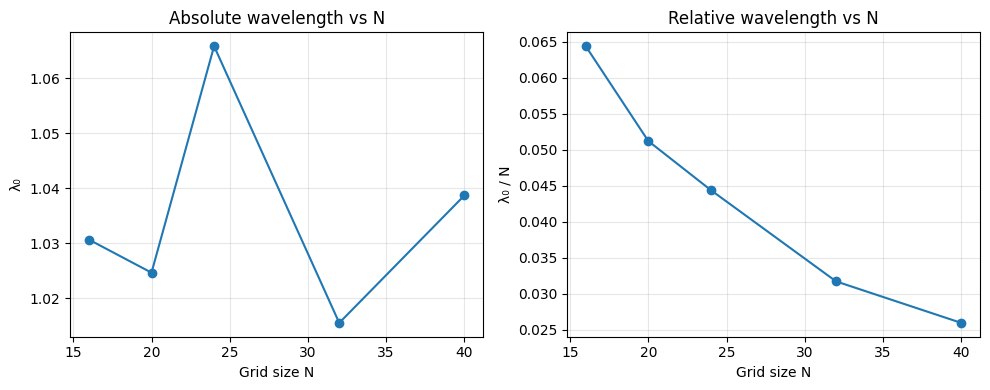

In [3]:
import matplotlib.pyplot as plt

N_sweep = [16, 20, 24, 32, 40]
D = 4
alpha = 0.2
beta = 0.001
steps = 50

lam_vs_N = []
lam_over_N = []

for N in N_sweep:
    s = initialize_with_seeds(D, N, seed=0)
    s = evolve_field(s, alpha=alpha, beta=beta, steps=steps)
    lam = measure_lambda_with_DC_masking(s)
    lam_vs_N.append(lam)
    lam_over_N.append(lam / N)

plt.figure(figsize=(10,4))

# Absolute wavelength
plt.subplot(1,2,1)
plt.plot(N_sweep, lam_vs_N, 'o-', label='λ₀')
plt.xlabel('Grid size N'); plt.ylabel('λ₀')
plt.title('Absolute wavelength vs N')
plt.grid(True, alpha=0.3)

# Relative wavelength
plt.subplot(1,2,2)
plt.plot(N_sweep, lam_over_N, 'o-', label='λ₀/N')
plt.xlabel('Grid size N'); plt.ylabel('λ₀ / N')
plt.title('Relative wavelength vs N')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


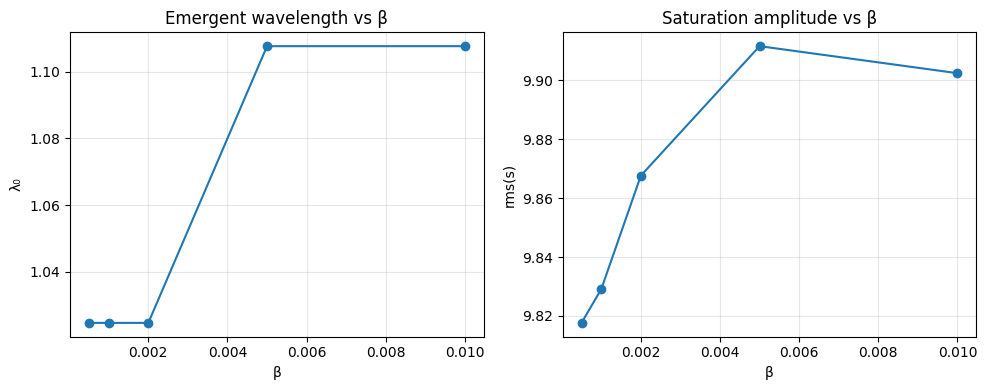

In [4]:
beta_values = [0.0005, 0.001, 0.002, 0.005, 0.01]
alpha = 0.2
D = 4
N = 20
steps = 50

lam_list = []
s_rms_list = []

for beta in beta_values:
    s = initialize_with_seeds(D, N, seed=0)
    s = evolve_field(s, alpha=alpha, beta=beta, steps=steps)
    lam = measure_lambda_with_DC_masking(s)
    lam_list.append(lam)
    s_rms = np.sqrt(np.mean(s**2))
    s_rms_list.append(s_rms)

plt.figure(figsize=(10,4))

# λ₀ vs β
plt.subplot(1,2,1)
plt.plot(beta_values, lam_list, 'o-')
plt.xlabel('β'); plt.ylabel('λ₀')
plt.title('Emergent wavelength vs β')
plt.grid(True, alpha=0.3)

# s_rms vs β
plt.subplot(1,2,2)
plt.plot(beta_values, s_rms_list, 'o-')
plt.xlabel('β'); plt.ylabel('rms(s)')
plt.title('Saturation amplitude vs β')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


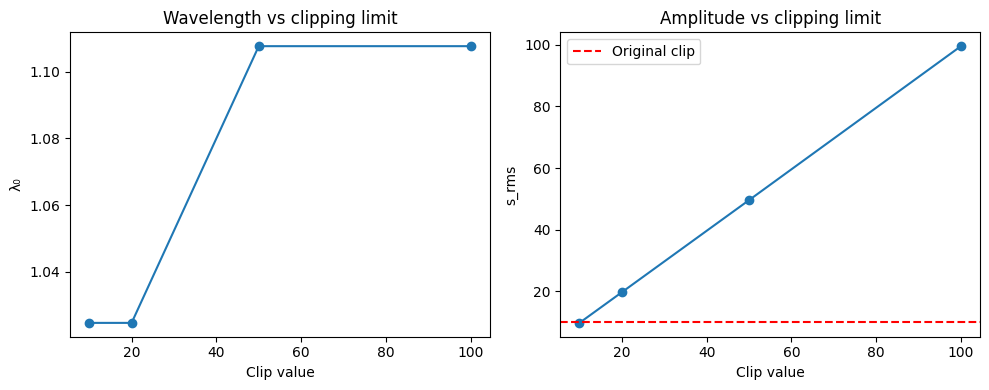

In [5]:
clip_values = [10, 20, 50, 100]
alpha = 0.2
beta = 0.001
D = 4
N = 20
steps = 50

lam_vs_clip = []
s_vs_clip = []

for clip_val in clip_values:
    s = initialize_with_seeds(D, N, seed=0)
    s = evolve_field(s, alpha=alpha, beta=beta, steps=steps, clip=clip_val)
    lam = measure_lambda_with_DC_masking(s)
    lam_vs_clip.append(lam)
    s_vs_clip.append(np.sqrt(np.mean(s**2)))

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(clip_values, lam_vs_clip, 'o-')
plt.xlabel('Clip value'); plt.ylabel('λ₀')
plt.title('Wavelength vs clipping limit')
plt.subplot(1,2,2)
plt.plot(clip_values, s_vs_clip, 'o-')
plt.axhline(10, color='r', linestyle='--', label='Original clip')
plt.xlabel('Clip value'); plt.ylabel('s_rms')
plt.title('Amplitude vs clipping limit')
plt.legend()
plt.tight_layout(); plt.show()